In [1]:
import numpy as np
# from PIL import Image
import taichi as ti
import taichi_volume_renderer as tvr
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization_3d, resample_polyline, get_volume, quaternion_to_rotation_matrix, rotation_matrix_to_quaternion

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


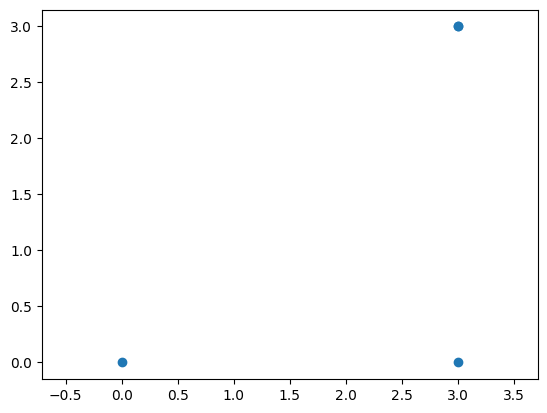

In [14]:
segment_length = 3  # 单段走廊的长度，在足够大的情况下，修改这个值不会影响沙发形状

def init_trajectory(control_point_num):  # 生成初始轨迹
    # 不旋转
    upsampled_trajectory = resample_polyline([
        [0, 0, 0, 1, 0, 0, 0],
        [segment_length, 0, 0, 1, 0, 0, 0],
        [segment_length, segment_length, 0, 1, 0, 0, 0],
        [segment_length, segment_length, segment_length, 1, 0, 0, 0],
    ], control_point_num)

    # A型旋转
    # upsampled_trajectory = resample_polyline([
    #     [0, 0, 0, 1, 0, 0, 0],
    #     [segment_length, 0, 0, 1, 0, 0, 0],
    #     [segment_length, 0, 0, 0.5 ** 0.5, 0, 0, 0.5 ** 0.5],  # 转90°
    #     [segment_length, segment_length, 0, 0.5 ** 0.5, 0, 0, 0.5 ** 0.5],
    #     [segment_length, segment_length, 0, 0.5, 0.5, -0.5, 0.5],  # 转90°
    #     [segment_length, segment_length, segment_length, 0.5, 0.5, -0.5, 0.5],
    # ], control_point_num)
    
    # B型旋转
    # upsampled_trajectory = resample_polyline([
    #     [0, 0, 0, 1, 0, 0, 0],
    #     [segment_length, 0, 0, 1, 0, 0, 0],
    #     [segment_length, 0, 0, 0.5 ** 0.5, 0, 0, 0.5 ** 0.5],  # 转90°
    #     [segment_length, segment_length, 0, 0.5, 0.5, 0.5, 0.5],  # 一边行进一边侧转90°
    #     [segment_length, segment_length, 0, 0, 0.5 ** 0.5, 0, 0.5 ** 0.5],  # 转90°
    #     [segment_length, segment_length, segment_length, 0, 0.5 ** 0.5, 0, 0.5 ** 0.5],
    # ], control_point_num)
    
    # C型旋转
    # upsampled_trajectory = resample_polyline([
    #     [0, 0, 0, 1, 0, 0, 0],
    #     [segment_length, 0, 0, 1, 0, 0, 0],
    #     [segment_length, 0, 0, 0.5, 0.5, 0.5, 0.5],
    #     [segment_length, segment_length, 0, 0.5, 0.5, 0.5, 0.5],
    #     [segment_length, segment_length, 0, -0.5, 0.5, 0.5, 0.5],
    #     [segment_length, segment_length, segment_length, -0.5, 0.5, 0.5, 0.5],
    # ], control_point_num)

    # upsampled_trajectory[1:-1] += np.random.randn(control_point_num - 2, upsampled_trajectory.shape[1]) * 0.1  # 添加噪声
    xs = upsampled_trajectory[:, 0]
    ys = upsampled_trajectory[:, 1]
    zs = upsampled_trajectory[:, 2]
    rotations = upsampled_trajectory[:, 3:7]  # 四元数数组
    rotations /= np.linalg.norm(rotations, axis=1, keepdims=True)  # 归一化
    return xs, ys, zs, rotations

xs, ys, zs, rotations = init_trajectory(  # 初始轨迹
    control_point_num=4
        # 轨迹的控制点数量 16 5 6
)

plt.scatter(xs, ys)
plt.axis('equal')
plt.show()

Text(0.5, 1.0, 'Trajectory of Movement')

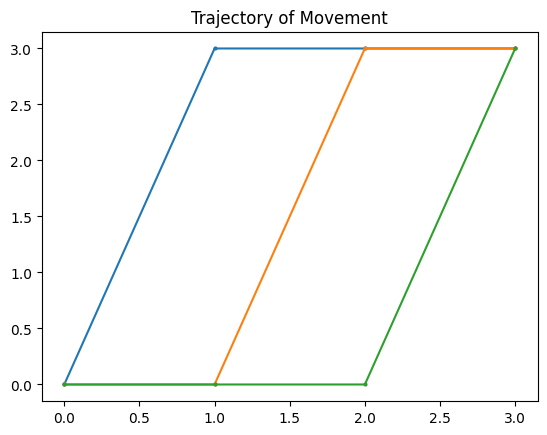

In [15]:
plt.plot(xs, markersize=2, marker='o')
plt.plot(ys, markersize=2, marker='o')
plt.plot(zs, markersize=2, marker='o')
plt.title('Trajectory of Movement')

In [16]:
np.stack([xs, ys, zs] + list(rotations.T), axis=1)

array([[0., 0., 0., 1., 0., 0., 0.],
       [3., 0., 0., 1., 0., 0., 0.],
       [3., 3., 0., 1., 0., 0., 0.],
       [3., 3., 3., 1., 0., 0., 0.]])

In [17]:
np.save('../trajectory/两个直角拐弯_不旋转/sofa_0.npy', np.stack([xs, ys, zs] + list(rotations.T), axis=1))

In [3]:
# 定义哪里是墙

from utils import test_forbidden_function_3d

@ti.func
def is_forbidden(x1, y1, z1):  # 指定哪里是墙
    return not ((abs(y1) <= 0.5 and abs(z1) <= 0.5 and x1 <= segment_length + 0.5) or (abs(x1 - segment_length) <= 0.5 and abs(z1) <= 0.5 and y1 >= -0.5 and y1 <= segment_length + 0.5) or (abs(x1 - segment_length) <= 0.5 and abs(y1 - segment_length) <= 0.5 and z1 >= -0.5))  # 三段走廊

# image = test_forbidden_function_3d(is_forbidden, -1, segment_length + 1, -1, segment_length + 1, -1, segment_length + 1, 64)
# tvr.plot_volume(1 - image, init_taichi=False)  # 可视化可通行区域

In [6]:
trajectory = np.load('../trajectory/两个直角拐弯_a型旋转_1/sofa_3000.npy')
xs = trajectory[:, 0]
ys = trajectory[:, 1]
zs = trajectory[:, 2]
rotations = trajectory[:, 3:]

len(xs)

113

In [ ]:
# rotations[0] = [0.5 ** 0.5, 0, 0, -0.5 ** 0.5]  # 第一个旋转改为-90度，绕z轴旋转
# rotations[-1] = [0.5 ** 0.5, 0, 0, 0.5 ** 0.5]  # 最后一个旋转改为90度，绕z轴旋转

In [ ]:
# 对称化函数

# def symmetrize_list(array):  # 识别对称性，自动将一个用列表表示的函数改造成奇函数或偶函数。支持任意维的数组，只有第一个轴被视为因变量变化的方向
#     symmetrized_array_0 = (array + array[::-1]) * 0.5  # 偶函数化
#     symmetrized_array_1 = (array - array[::-1]) * 0.5  # 奇函数化
#     if np.sum((symmetrized_array_0 - array) ** 2) < np.sum((symmetrized_array_1 - array) ** 2):  # 更接近偶函数
#         return symmetrized_array_0
#     else:  # 更接近奇函数
#         return symmetrized_array_1

# def symmetrize(xs, ys, zs, rotations):  # 对称化，其中的对称性是人为指定的。注意指定对称性可能会导致搜索不到真正的最优解
#     xs = symmetrize_list(xs)
#     ys = symmetrize_list(ys)
#     zs = symmetrize_list(zs)
#     for i in range(4):
#         rotations[:, i] = symmetrize_list(rotations[:, i])

#     # 增加轨迹的对称性，其合理性是从数值结果中观察出来的
#     ys = (ys - zs) * 0.5
#     zs = -ys
#     # rotations[:, 2] = (rotations[:, 2] - rotations[::-1, 3]) * 0.5
#     # rotations[:, 3] = -rotations[::-1, 2]

#     rotations /= np.linalg.norm(rotations, axis=1, keepdims=True)  # 归一化

#     return xs, ys, zs, rotations

In [ ]:
sofa_w = 3.5  # 求解域的尺寸
sofa_h = 1
sofa_d = 1

best_score, xs, ys, zs, rotations, rotation_matrices, sofa, maximal_volume_record = run_optimization_3d(
    is_forbidden,
    # 一开始解除注释这三个
    xs,
    ys,
    zs,
    rotations,
    
    # 精炼结果时解除注释这三个
    # zoom(xs, zoom=2, order=1),  # 上采样以获得更精确的轨道
    # zoom(ys, zoom=2, order=1),  # 上采样以获得更精确的轨道
    # zoom(zs, zoom=2, order=1),  # 上采样以获得更精确的轨道
    # zoom(rotations, zoom=(2, 1), order=1),  # 上采样以获得更精确的轨道

    sofa_w=sofa_w,
    sofa_h=sofa_h,
    sofa_d=sofa_d,
    mutation_sigma_pos=0.1,  # 变异率，越到后期应该使用越低的变异率 0.1 0.05 0.02 0.01 0.003
    mutation_sigma_rotation=0.1,  # 变异率，越到后期应该使用越低的变异率 0.1 0.05 0.02 0.01 0.003
    auto_adjust_mutation_rate=True,  # 自动调整变异率
    # symmetrize_function=symmetrize,
    iterations=250000,  # 20000
    auto_divide_trajectory = True,  # 自动细分轨迹
    trajectory_upsampling=41,  # 41 101 73
    regularization=0.02,  # 正则化 0.02
    regularization_mode='L2',  # 正则化模式，可以是'L1'或'L2'
    resolution=256,  # 64 80
    print_every=500,  # 1000 500
    save_image_every=50,
    save_image_path='../images/两个直角拐弯_c型旋转_2/sofa_',
    save_image_start_id=0,  # 文件起始编号，精炼结果时需要设置
    save_trajectory_path='../trajectory/两个直角拐弯_c型旋转_2/sofa_'
)
print(f"Estimated maximal sofa volume (by sampling): {best_score:.5f}")

initial volume = 0.8469275832176208, initial loss = -0.797408314907926
iter 500 / 250000, maximal_volume = 0.8469275832176208, loss = -0.797408314907926
iter 1000 / 250000, maximal_volume = 0.8678677082061768, loss = -0.8189269664504489
iter 1500 / 250000, maximal_volume = 0.9043166637420654, loss = -0.854823072391727
iter 2000 / 250000, maximal_volume = 0.9068771004676819, loss = -0.8580236923271176
iter 2500 / 250000, maximal_volume = 1.0351371765136719, loss = -0.9870605575517571
iter 3000 / 250000, maximal_volume = 1.1469340324401855, loss = -1.0990512283976634
iter 3500 / 250000, maximal_volume = 1.1616270542144775, loss = -1.1137507997535325
iter 4000 / 250000, maximal_volume = 1.2156294584274292, loss = -1.1661293623314994
iter 4500 / 250000, maximal_volume = 1.2209171056747437, loss = -1.1712870115911307
iter 5000 / 250000, maximal_volume = 1.2245166301727295, loss = -1.1746196870938348
iter 5500 / 250000, maximal_volume = 1.2301249504089355, loss = -1.1807994188441098
iter 600

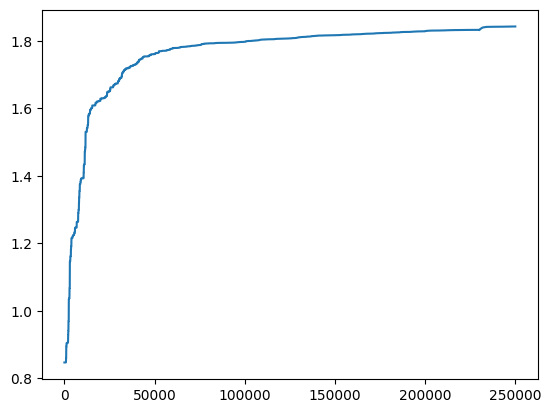

In [6]:
plt.plot(maximal_volume_record)

In [7]:
len(set(maximal_volume_record)) / len(maximal_volume_record)  # 0.005比较合适

0.006632

In [8]:
f'最终面积 / 最初面积 = {maximal_volume_record[-1] / maximal_volume_record[0]}'

'最终面积 / 最初面积 = 2.175933189796079'

In [9]:
sofa.shape

(256, 73, 73)

In [15]:
def pad_to_cube_center(arr):
    """
    通过填充0将三维数组补成正方体，原始数据位于中心。
    
    参数:
        arr (np.ndarray): 输入的三维数组
    
    返回:
        np.ndarray: 填充后的正方体数组
    """
    # 获取各维度大小
    d, h, w = arr.shape
    
    # 确定正方体的边长（取最大维度）
    max_side = max(d, h, w)
    
    # 计算各维度需要填充的总量
    pad_d = max_side - d
    pad_h = max_side - h
    pad_w = max_side - w
    
    # 计算前后填充量（使原数据居中）
    pad_before_d = pad_d // 2
    pad_after_d = pad_d - pad_before_d
    
    pad_before_h = pad_h // 2
    pad_after_h = pad_h - pad_before_h
    
    pad_before_w = pad_w // 2
    pad_after_w = pad_w - pad_before_w
    
    # 执行填充
    padded = np.pad(arr, 
                    ((pad_before_d, pad_after_d),
                     (pad_before_h, pad_after_h),
                     (pad_before_w, pad_after_w)),
                    mode='constant', constant_values=0)
    
    return padded

tvr.plot_volume(pad_to_cube_center(sofa), smoke_density_factor=10, camera_phi=45, camera_theta=30, init_taichi=False)

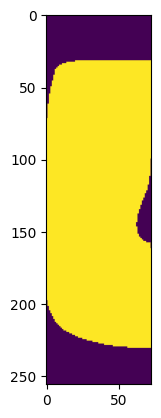

In [11]:
plt.imshow(np.max(sofa, axis=2))

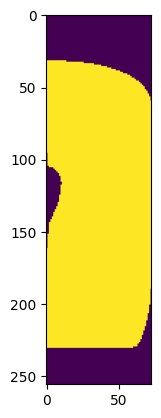

In [12]:
plt.imshow(np.max(sofa, axis=1))

Text(0.5, 1.0, 'Trajectory of Movement')

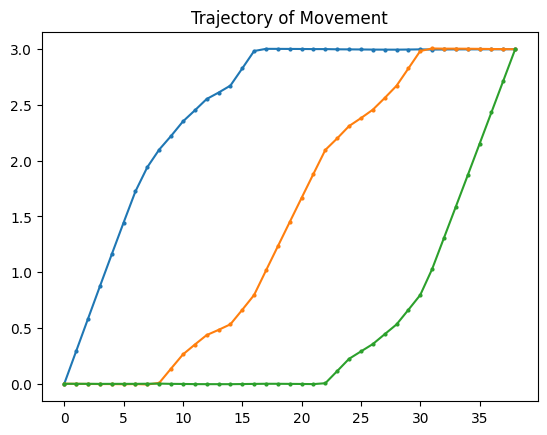

In [13]:
plt.plot(xs, markersize=2, marker='o')
plt.plot(ys, markersize=2, marker='o')
plt.plot(zs, markersize=2, marker='o')
plt.title('Trajectory of Movement')

Text(0.5, 1.0, 'Trajectory of Rotation (Quaternion)')

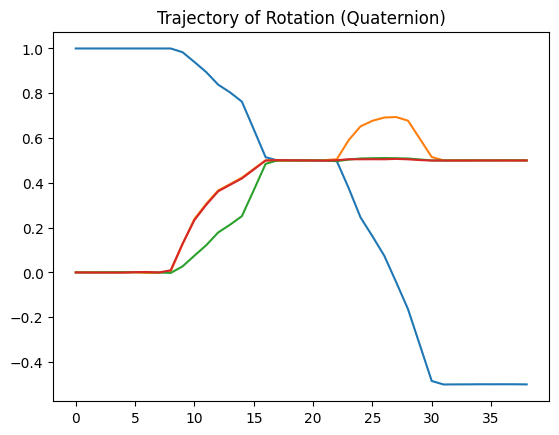

In [14]:
plt.plot(rotations[:, 0])
plt.plot(rotations[:, 1])
plt.plot(rotations[:, 2])
plt.plot(rotations[:, 3])
plt.title('Trajectory of Rotation (Quaternion)')

In [48]:
rotation_matrix = quaternion_to_rotation_matrix(rotations[-1])
rotation_matrix

array([[-2.220446e-16,  0.000000e+00,  1.000000e+00],
       [ 0.000000e+00, -1.000000e+00,  0.000000e+00],
       [ 1.000000e+00,  0.000000e+00, -2.220446e-16]], dtype=float32)

## 用2d沙发构造下界

In [11]:
# 导入PNG图片为NumPy数组
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
image_array = np.array(Image.open('../hq_images/单拐角.png').convert('L')) > 0  # 导入图片并二值化
np.sum(image_array) / image_array.shape[0] ** 2

np.float64(2.2134578166549606)

In [ ]:
# A型旋转下界

float(np.sum(np.logical_and(image_array[np.newaxis, :, :], image_array[:, np.newaxis, :])) / image_array.shape[0] ** 3)

1.7504199011512154

In [18]:
# B型旋转下界

disk_mask = np.zeros((image_array.shape[0], image_array.shape[0]), dtype=bool)
ii, jj = np.meshgrid(np.arange(image_array.shape[0]), np.arange(image_array.shape[0]))
disk_mask[(ii - image_array.shape[0] // 2) ** 2 + (jj - image_array.shape[0] // 2) ** 2 <= (image_array.shape[0] // 2) ** 2] = True
# plt.imshow(disk_mask)

float(np.sum(np.logical_and(image_array[np.newaxis, :, :], disk_mask[:, :, np.newaxis])) / image_array.shape[0] ** 3)

1.7709138371824145